### **Praktikum Naive Bayes**
ada beberapa tahap yang perlu dilakukan pada praktikum dataset kali ini, yaitu preprocessing, eksplorasi data, visualisasi, melatih model, dan evaluasi performa menggunakan algoritma Gaussian Naive Bayes dengan dataset Breast Cancer Wisconsin

## **Persiapan dan membersihkan data**
pada tahap ini, dataset akan dicek struktur dan missing.

In [1]:
# import library utama untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# library scikit-learn untuk split data, preprocessing, model, dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
# untuk membaca file dari drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# membaca dataset CSV dari drive
data = pd.read_csv('/content/drive/MyDrive/ML/Tugas/Tugas9/data/data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# membaca dataset baris 5 terakhir
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [4]:
# mengecek baris dan kolom dataset
data.shape

(569, 33)

In [5]:
# mengecek info dataset, infonya berisi jumlah baris, jumlah kolom, tipe data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# mengecek missing value
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Menghapus kolom yang tidak diperlukan dan tidak relevan

In [7]:
# menghapus kolom yang tidak diperlukan seperti kolom 'id', dan kolom kosong seperti 'Unnamed: 32'
data = data.drop(columns=['id', 'Unnamed: 32'])

In [8]:
# mengecek kembali info dataset, untuk memastikan data yang sudah dihapus benar benar sudah hilang
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Visualisasi

In [12]:
# mengganti nilai label diagnosis menjadi numerik, karena tipe datanya masih object. jadi yang berlabel 'B' bernilai 0 dan M bernilai '1'
replacements = {'diagnosis':{'B': 0, 'M': 1}}

data.replace(replacements, inplace=True)

/tmp/ipython-input-420990360.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(replacements, inplace=True)


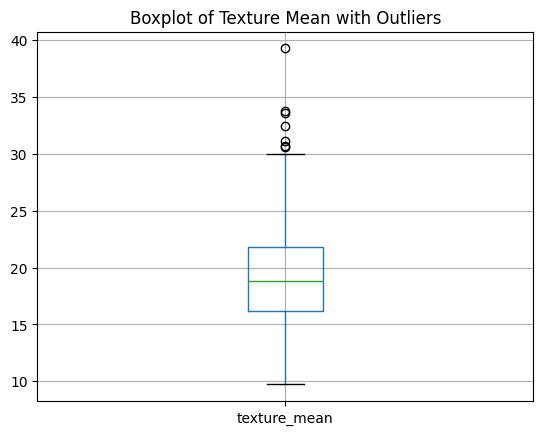

In [9]:
# membuat boxplot kolom 'texture_mean' untuk melihat distribusi dan outlier
data.boxplot(column=['texture_mean'])
plt.title('Boxplot of Texture Mean with Outliers')
plt.show()

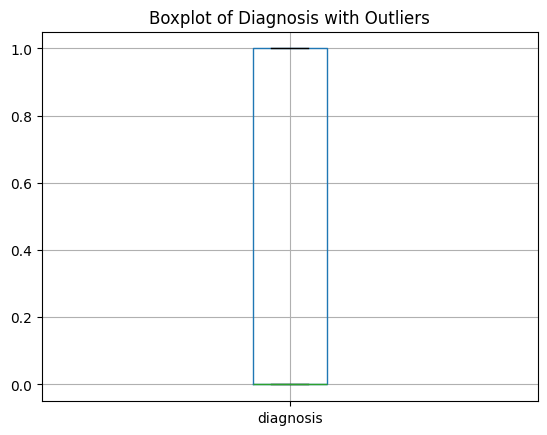

In [21]:
data.boxplot(column=['diagnosis'])
plt.title('Boxplot of Diagnosis with Outliers')
plt.show()

## Countplot

Jumlah data diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


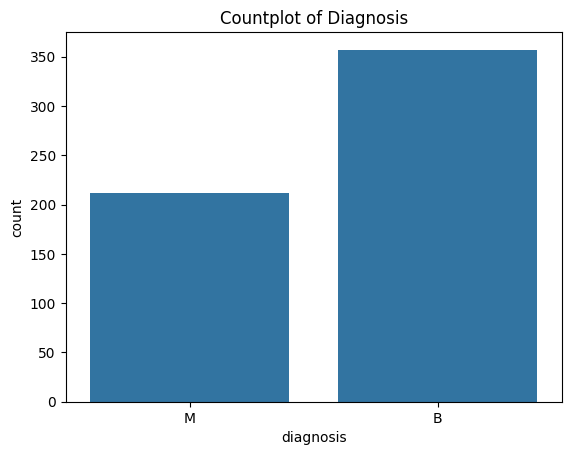

In [10]:
# membuat countplot untuk melihat distribusi target yaitu kolom diagnosis yang berisi jumlah diagnosis kanker jinak dan ganas
sns.countplot(x='diagnosis', data=data)
plt.title('Countplot of Diagnosis')
print("Jumlah data diagnosis:")
print(data['diagnosis'].value_counts()) # mencetak jumlah masing-masing kelas
plt.show()

In [11]:
# menampilkan statistik deskriptif mulai dari mean, count, standar deviasi, minimal, maksimal, quartil untuk kolom numerik
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


radius_mean | Malignant: 212 data, Benign: 357 data
texture_mean | Malignant: 212 data, Benign: 357 data
perimeter_mean | Malignant: 212 data, Benign: 357 data
area_mean | Malignant: 212 data, Benign: 357 data


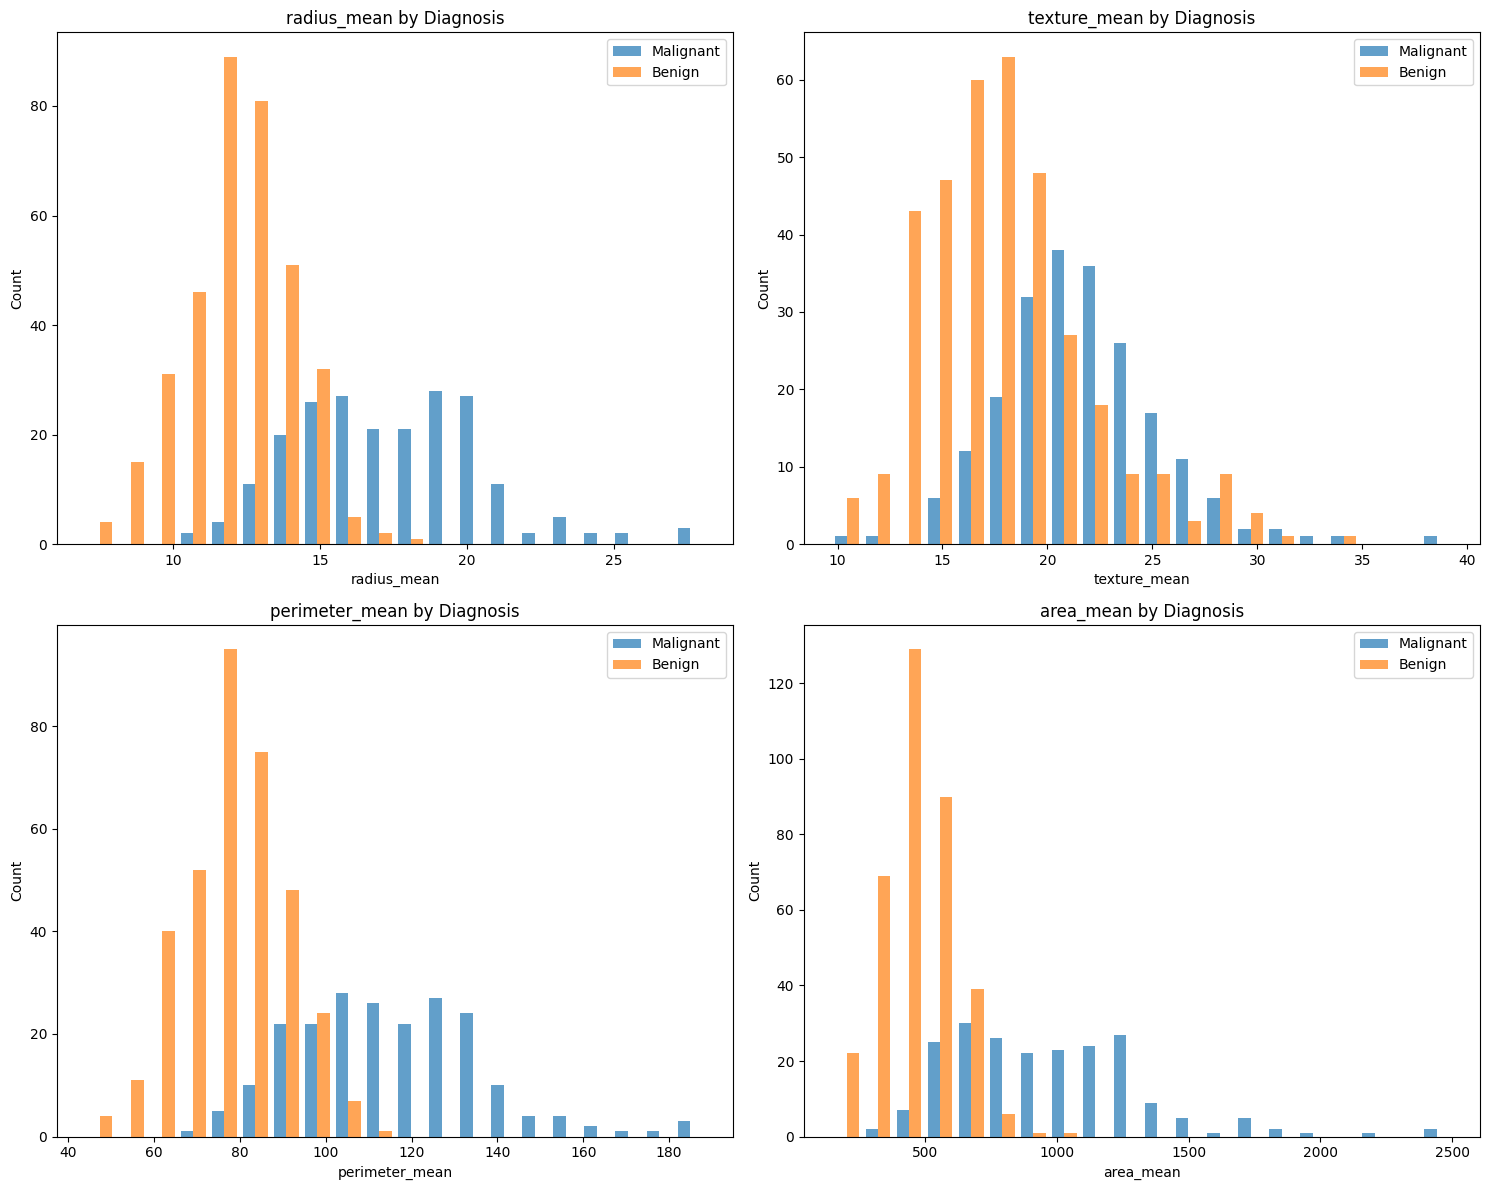

In [13]:
# visualisasi beberapa fitur yang dipilih yaitu kolom radius_mean, texture_mean, perimeter_mean, area_mean. serta diagnosisnya dilihat perkelas agar jelas perbedaan distribusinya
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

for ax, feature in zip(axes.flatten(), features):
    # memisahkan nilai fitur berdasarkan diagnosis, dan ada fungsi dropna yang digunakan sebagai bentuk menghindari nilai NaN
    malignant = data[data['diagnosis'] == 1][feature].dropna()
    benign = data[data['diagnosis'] == 0][feature].dropna()

    # mencetak jumlah data tiap kelas fitur yang sudah ditentukan, hasilnya dapt membantu untuk mendiagnosis ketidakseimbangan dan juga missing
    print(f"{feature} | Malignant: {len(malignant)} data, Benign: {len(benign)} data")

    # membuat histogram untuk membandingkan distribusi antar kelas
    ax.hist([malignant, benign], bins=20, label=['Malignant', 'Benign'], alpha=0.7)
    ax.set_title(f'{feature} by Diagnosis')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# menyusun fitur bervariabel X dan target yang bervariabel Y
X = data.drop(columns=['diagnosis'])
Y = data['diagnosis']

## Splitting dan standarisasi data

In [15]:
# Membagi dataset menjadi data testing dan data training. ketentuannya data testing sebanyak 20% dari data yang ada, dan sisanya 80% untuk data training.
# guna dari stratify=Y untuk mempertahankan proporsi kelas saat pembagian
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42) # random_state untuk mendapatkan hasil eksperimen atau penelitian yang konsisten
print(X.shape, X_train.shape, X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(569, 30) (455, 30) (114, 30)


## Pelatihan model naive bayes

In [16]:
from sklearn.naive_bayes import GaussianNB
# inisialisasi dan training model naive bayes, karena model ini cocok untuk fitur numerik kontinu
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

GaussianNB()

In [17]:
# memprediksi data training dan testing untuk mengecek performa
train_pred_nb = nb_model.predict(X_train_scaled)
test_pred_nb = nb_model.predict(X_test_scaled)

# menghitung akurasi pada training dan testing
print("Training Accuracy (NB): ", accuracy_score (Y_train, train_pred_nb))
print("Testing Accuracy (NB): ", accuracy_score (Y_test, test_pred_nb))

Training Accuracy (NB):  0.945054945054945
Testing Accuracy (NB):  0.9210526315789473


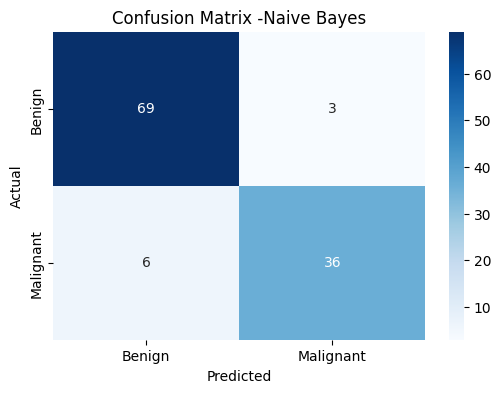

In [18]:
#Visualisasi Confusion Matrix (Naive Bayes)
plt.figure(figsize=(6,4))
cm_nb = confusion_matrix(Y_test, test_pred_nb)

# membuat heatmap untuk memudahkan melihat perbandingan antara kenyataan sebenarnya dengan hasil prediksi
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix -Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Evaluasi model

In [19]:
# mencetak classification report, mulai dari precision, recall, f1-score, support
print("\nClassification Report (NB):")
print(classification_report(Y_test, test_pred_nb))


Classification Report (NB):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [20]:
# evaluasi model menggunakan cross-validation 5-fold pada seluruh dataset
# gunanya untuk memberikan gambaran performa model yang lebih stabil jika dibandingkan dengan satu kali p
from sklearn.model_selection import cross_val_score
cv_nb = cross_val_score(nb_model, X, Y, cv = 5, scoring='accuracy')
print("\nNaive Bayes Cross Validation Accuracy (5-Fold):")
print("Scores:", cv_nb)
print("Mean Accuracy:", cv_nb.mean())
print("Std Deviation:", cv_nb.std())


Naive Bayes Cross Validation Accuracy (5-Fold):
Scores: [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Mean Accuracy: 0.9385188635305075
Std Deviation: 0.014585994424363306


## **Kesimpulan**
Melalui praktikum, dihasilkan bahwa model Gaussian Naive Bayes terbukti efekstif dan memiliki performa tinggi dalam mengklasifikasikan kanker payudara.
Adapula faktor yang mendukung keberhasilan analisis, yaitu dataset yang digunakan sudah bersih dari segala missing value, informatif, fitur-fitur yang dipilih sesuai dengan dugaan GaussianNB, jelasnya perbedaan distribusi antara Benign & Malignant, dan terakhir standarisasi data yang membantu kestabilan model.
melalui hasil analisis pada praktikum, dihasilkan akurasi yang tinggi pada testing maupun saat cross validation, jadi model ini layak menjadi acuan untuk mendeteksi dini kanker payudara dengan metode machine learning yang ringan dan cepat.